In [1]:
import networkx as nx
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.cm as cmx
import matplotlib.colors as colors

from sklearn import metrics
import matplotlib.pyplot as plt
import copy
import scipy.sparse as sp
import scanpy as sc
import os
import anndata as ad
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
gene_TCR = ad.read_h5ad('./10Xdatasets/gex_merge_log1_5000_genes_all_peptides.h5ad')
gene_TCR.obs['used_ix'] = range(gene_TCR.shape[0])
donor_3 = gene_TCR[gene_TCR.obs.donor == 'donor3']
donor_3

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 30234 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', '

In [3]:
data_10X_dat = donor_3.obs
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
GTGTGCGGTGAGGGTT-5,TRAV1-2,TRBV6-4,None,TRBD1,TRAJ20,TRBJ2-3,TRAC,TRBC1,CAVRDRDYKLSF,CASSDSGGATDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101040,4315.0,3.634981,1562,0.050290,93852
TTTACTGTCGGAGGTA-6,TRAV27,TRBV4-1,None,TRBD1,TRAJ26,TRBJ1-2,TRAC,TRBC1,CAGDENYGQNFVF,CASSQVTQGAGYGYTF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101041,4389.0,3.642366,1650,0.064252,93853
ACAGCTATCAAACAAG-11,TRAV14DV4,TRBV19,None,TRBD1,TRAJ34,TRBJ2-7,TRAC,TRBC2,CAMREHNTDKLIF,CASKAGTGEYEQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101042,1809.0,3.257439,1028,0.112217,93854
TGCCCTAGTATAAACG-7,TRAV17,TRBV9,None,TRBD1,TRAJ40,TRBJ1-1,TRAC,TRBC1,CATAPSGTYKYIF,CASSVDTGFTEAFF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101043,1449.0,3.161068,771,0.140787,93855
CTAACTTTCATGTAGC-9,TRAV38-2DV8,TRBV11-2,None,None,TRAJ52,TRBJ2-2,TRAC,TRBC2,CASDAGGTSYGKLTF,CASGTGELFF,...,0.0,0.0,unknown,nan,101044,2115.0,3.325310,1313,0.032151,93856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACACGCGTCAGAAGC-5,TRAV12-3,TRBV29-1,None,None,TRAJ39,TRBJ1-2,TRAC,TRBC1,CAIGPGNMLTF,CSVDLEANYGYTF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134644,1410.0,3.149219,888,0.119858,124081
TGGGCGTGTTGGGACA-3,TRAV12-2,TRBV4-1,None,TRBD1,TRAJ39,TRBJ2-7,TRAC,TRBC2,CAIGPGNMLTF,CASSQGGRTGDYEQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134646,1106.0,3.043755,706,0.098553,124082
CAAGGCCCAAATACAG-12,TRAV8-6,TRBV11-3,None,TRBD1,TRAJ57,TRBJ2-5,TRAC,TRBC2,CAVSYQGGSEKLVF,CASSQTGLVLGGQETQYF,...,0.0,0.0,unknown,nan,134647,4164.0,3.619511,1550,0.059558,124083


In [4]:
from sklearn.decomposition import NMF

In [5]:
# model_nmf = NMF(n_components=100, init='random', random_state=0)
# model_nmf.fit(donor_3.X)

In [6]:
# W = model_nmf.transform(donor_3.X)
# H = model_nmf.components_

In [7]:
# W_df = pd.DataFrame(W)

In [8]:
# W_df

In [9]:
# all_embeddings_df = pd.read_csv('./data_10X_full_data_emb_dat_mvTCR_clean_PCAs_041.csv')
all_embeddings_df_alpha_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_alpha_chain_10X_donor_3_only.csv')
all_embeddings_df_beta_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_beta_chain_10X_donor_3_only.csv')


In [10]:
all_embeddings_df_beta_chain

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,173.911540,143.461690,83.570700,77.056694,0.0,0.000000,0.0,23.423512,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.159890,0.0
1,37.818950,172.070680,81.129000,0.000000,0.0,9.602502,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.166657,0.0
2,7.325249,77.249620,98.810240,71.064740,0.0,71.044190,0.0,58.321957,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,197.865660,66.389780,0.000000,108.656400,0.0,0.000000,0.0,35.673496,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.167640,0.0
4,80.119060,65.026306,90.473854,136.287630,0.0,45.472620,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30229,111.155260,152.690570,56.222790,91.850300,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30230,0.000000,123.957375,115.934560,0.000000,0.0,47.766438,0.0,17.525898,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30231,0.000000,148.454760,0.000000,126.250460,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30232,110.679090,75.655710,122.592300,0.000000,0.0,0.000000,0.0,37.348400,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [11]:

# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain, W_df], axis=1)
# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain], axis=1)
all_embed = all_embeddings_df_beta_chain
all_embed

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,173.911540,143.461690,83.570700,77.056694,0.0,0.000000,0.0,23.423512,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.159890,0.0
1,37.818950,172.070680,81.129000,0.000000,0.0,9.602502,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.166657,0.0
2,7.325249,77.249620,98.810240,71.064740,0.0,71.044190,0.0,58.321957,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,197.865660,66.389780,0.000000,108.656400,0.0,0.000000,0.0,35.673496,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.167640,0.0
4,80.119060,65.026306,90.473854,136.287630,0.0,45.472620,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30229,111.155260,152.690570,56.222790,91.850300,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30230,0.000000,123.957375,115.934560,0.000000,0.0,47.766438,0.0,17.525898,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30231,0.000000,148.454760,0.000000,126.250460,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
30232,110.679090,75.655710,122.592300,0.000000,0.0,0.000000,0.0,37.348400,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [12]:
import anndata as ad

In [13]:
donor_1_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           
donor_2_peptides = ['B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder',          
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder']      
donor_3_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',           
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'B0801_RAKFKQLL_BZLF1_EBV_binder']            
donor_4_peptides = ['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',       
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           

In [14]:
top16_peptide = data_10X_dat.antigen.value_counts().index.to_list()
top16_peptide

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'unknown',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'A0201_CLLWSFQTSA_Tyrosinase_Cancer_binder',
 'B0702_QPRAPIRPI_EBNA-6_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_RMFPNAPYL_WT-1_binder',
 'B3501_IPSINVHHY_pp65_CMV_binder',
 'A2402_CYTWNQMNL_WT1-(235-243)236M_Y_binder',
 'B0801_ELRRKMMYM_IE-1_CMV_binder',
 'A0201_IMDQVPFSV_gp100_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase_binder',
 'A0201_NLVPMVATV_pp65_CMV_binder',
 'A0201_SLLMWITQV_NY-E

In [15]:
data_10X_dat.columns

Index(['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA',
       'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB',
       'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor',
       'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA',
       'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b',
       'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV',
       'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer',
       'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer',
       'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer',
       'A0201_KVLEYVIKV_MAGE-A1_Cancer',
       'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase',
       'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91',
       'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV',
       'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza',
       'A0201_GLCTLVAML_BML

In [16]:
top16_peptide[1:10]

['unknown',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder']

In [17]:
bind_list = top16_peptide[1:10]
bind_list.append('unknown')
bind_list

['unknown',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'unknown']

In [18]:
from distinctipy import distinctipy

colors_distinct = distinctipy.get_colors(len(bind_list)-1)


In [19]:
colors_distinct.append((0.75,0.75,0.75))
colors_distinct

[(0.0, 1.0, 0.0),
 (1.0, 0.0, 1.0),
 (0.0, 0.5, 1.0),
 (1.0, 0.5, 0.0),
 (0.5, 0.75, 0.5),
 (0.3730438784710949, 0.008427097096129987, 0.6195069276039589),
 (0.8032160445705688, 0.5181655726061932, 0.9956100484206948),
 (0.7225878949257194, 0.013185359423765641, 0.02978984360555459),
 (0.17729040575915955, 0.9831065126132674, 0.9734583584272906),
 (0.75, 0.75, 0.75)]

In [20]:
antigen_colors = dict(map(lambda i,j : (i,j) , bind_list,colors_distinct))
antigen_colors

{'unknown': (0.75, 0.75, 0.75),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (1.0, 0.0, 1.0),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.0, 0.5, 1.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.5, 0.75, 0.5),
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder': (0.3730438784710949,
  0.008427097096129987,
  0.6195069276039589),
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder': (0.8032160445705688,
  0.5181655726061932,
  0.9956100484206948),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.7225878949257194,
  0.013185359423765641,
  0.02978984360555459),
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder': (0.17729040575915955,
  0.9831065126132674,
  0.9734583584272906)}

In [21]:
top16_peptide[1:10]

['unknown',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder']

In [22]:

from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_3
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_3_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([35]):
    for resolution in [ 0.3]:
        for n_neighbors in [15]:
            sc.pp.neighbors(adata_gene, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_gene, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_gene.obs['leiden'].astype('int').values,
                adata_gene.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
  0%|          | 0/1 [00:00<?, ?it/s]2026-03-03 11:35:10.292700: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 11:35:10.422393: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly differ

Resolution: 0.3, N_neighbors: 15, NMI Score: 0.008180201114652395, PCs: 35
Best NMI Score: 0.008180201114652395 at Resolution: 0.3, N_neighbors: 15, PCs: 35


In [23]:
from sklearn.metrics.cluster import adjusted_rand_score

In [24]:
from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_3
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_3_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
sc.pp.neighbors(adata_gene, n_neighbors=best_n_neighbors, n_pcs=best_npcs)
# sc.pp.neighbors(adata_gene, n_neighbors=10, n_pcs=35)
sc.tl.leiden(adata_gene, resolution=0.3)
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


0.003418588415279705

In [25]:
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.008180201114652395

In [26]:
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.003418588415279705

In [27]:

adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

-4.143337273922563e-05

In [28]:
normalized_mutual_info_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.0416690081375964

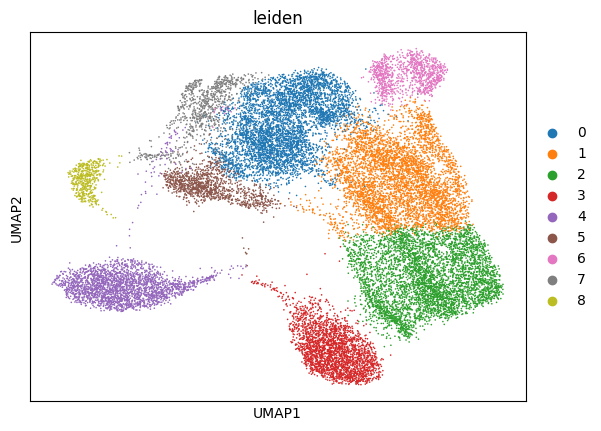

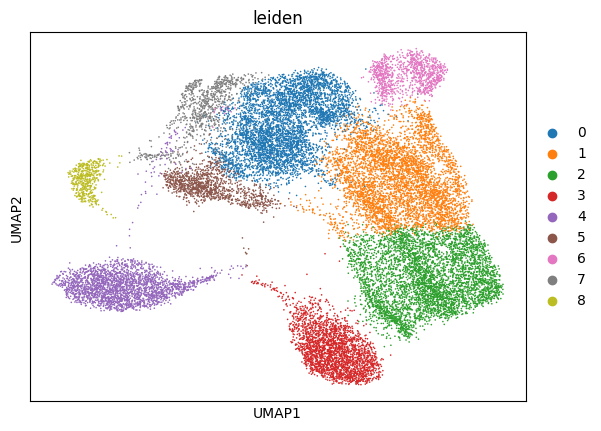

In [29]:
sc.tl.umap(adata_gene)
sc.pl.umap(adata_gene, color=['leiden'])
sc.pl.umap(adata_gene, color=['leiden'])

In [30]:
antigen_colors

{'unknown': (0.75, 0.75, 0.75),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (1.0, 0.0, 1.0),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.0, 0.5, 1.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.5, 0.75, 0.5),
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder': (0.3730438784710949,
  0.008427097096129987,
  0.6195069276039589),
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder': (0.8032160445705688,
  0.5181655726061932,
  0.9956100484206948),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.7225878949257194,
  0.013185359423765641,
  0.02978984360555459),
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder': (0.17729040575915955,
  0.9831065126132674,
  0.9734583584272906)}

In [31]:
# color_palette = [antigen_colors[cat] for cat in bind_list]
# sc.pl.umap(
#     adata_gene, 
#     color=['antigen'], 
#     palette=antigen_colors
# )

In [32]:
normalized_mutual_info_score(
    adata_gene.obs['leiden'].astype('int').values,
    adata_gene.obs['peptide'].astype('category').cat.codes.values
)

0.008180201114652395

In [33]:
from sklearn.metrics.cluster import adjusted_rand_score
ari_score = adjusted_rand_score(adata_gene.obs['leiden'].astype('int').values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.003418588415279705


In [34]:
adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.003418588415279705


In [35]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(donor_3_peptides)]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([35]):
    for resolution in [ 0.4]:
        for n_neighbors in [ 20]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
100%|██████████| 1/1 [00:15<00:00, 15.24s/it]

Resolution: 0.4, N_neighbors: 20, NMI Score: 0.002638875716052836, PCs: 35
Best NMI Score: 0.002638875716052836 at Resolution: 0.4, N_neighbors: 20, PCs: 35


In [36]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
GTGTGCGGTGAGGGTT-5,TRAV1-2,TRBV6-4,None,TRBD1,TRAJ20,TRBJ2-3,TRAC,TRBC1,CAVRDRDYKLSF,CASSDSGGATDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101040,4315.0,3.634981,1562,0.050290,93852,1
TTTACTGTCGGAGGTA-6,TRAV27,TRBV4-1,None,TRBD1,TRAJ26,TRBJ1-2,TRAC,TRBC1,CAGDENYGQNFVF,CASSQVTQGAGYGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101041,4389.0,3.642366,1650,0.064252,93853,0
ACAGCTATCAAACAAG-11,TRAV14DV4,TRBV19,None,TRBD1,TRAJ34,TRBJ2-7,TRAC,TRBC2,CAMREHNTDKLIF,CASKAGTGEYEQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101042,1809.0,3.257439,1028,0.112217,93854,3
TGCCCTAGTATAAACG-7,TRAV17,TRBV9,None,TRBD1,TRAJ40,TRBJ1-1,TRAC,TRBC1,CATAPSGTYKYIF,CASSVDTGFTEAFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101043,1449.0,3.161068,771,0.140787,93855,1
GAACATCCACAACGTT-5,TRAV17,TRBV6-3,None,TRBD1,TRAJ54,TRBJ1-5,TRAC,TRBC1,CATDVQGAQKLVF,CASSYISGGNQPQHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101046,1748.0,3.242541,910,0.128719,93857,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCGAAAGTCCGAATT-3,TRAV27,TRBV27,None,TRBD1,TRAJ44,TRBJ1-2,TRAC,TRBC1,CAGADGTASKLTF,CASSLSGTWGEGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134642,3745.0,3.573452,1448,0.024833,124079,1
AACTGGTGTGGTAACG-8,TRAV13-2,TRBV5-1,None,None,TRAJ45,TRBJ2-2,TRAC,TRBC2,CAEGGGGADGLTF,CASSLGATNTGELFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134643,2666.0,3.425860,1323,0.171043,124080,0
GACACGCGTCAGAAGC-5,TRAV12-3,TRBV29-1,None,None,TRAJ39,TRBJ1-2,TRAC,TRBC1,CAIGPGNMLTF,CSVDLEANYGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134644,1410.0,3.149219,888,0.119858,124081,2


In [37]:
adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

-0.001487093383275883

NMI Score: 0.002638875716052836


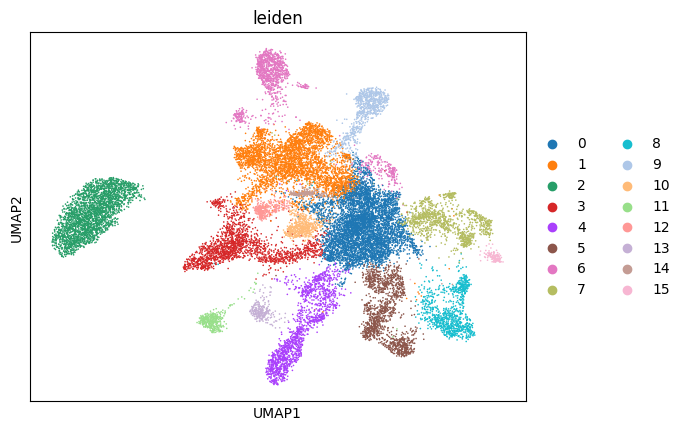

In [38]:
sc.pp.neighbors(adata_emb, n_neighbors = best_n_neighbors, n_pcs=best_npcs)
sc.tl.leiden(adata_emb, resolution=best_resolution)
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")
sc.tl.umap(adata_emb)
sc.pl.umap(adata_emb, color=['leiden'])

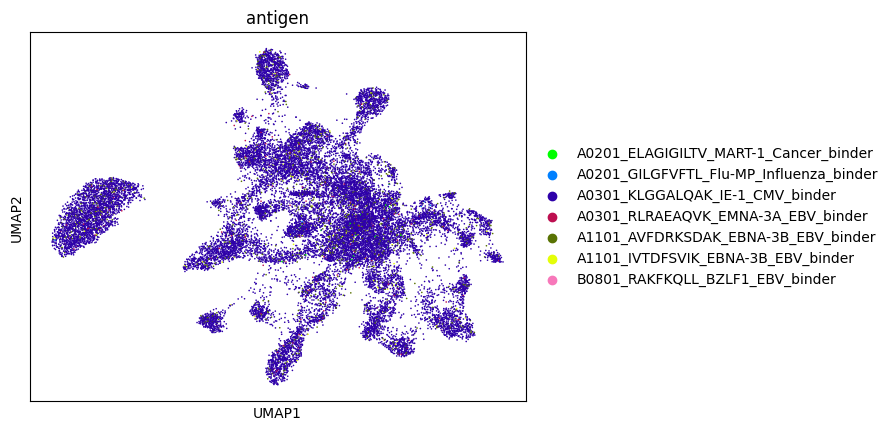

In [39]:
antigen_colors = {'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}
sc.pl.umap(
    adata_emb, 
    color=['antigen'], 
    palette=antigen_colors
)

In [40]:
# adata_emb.obs['antigen_color'] = [antigen_colors[x] for x in adata_emb.obs['antigen'].values]
# adata_emb.obs

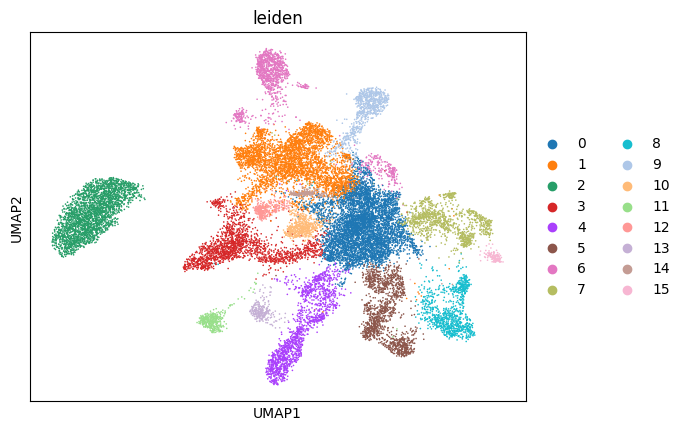

In [41]:
sc.pl.umap(adata_emb, color=['leiden'])

In [42]:
adata_emb.obs['antigen'].value_counts()

antigen
A0301_KLGGALQAK_IE-1_CMV_binder            20601
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder         1258
A0301_RLRAEAQVK_EMNA-3A_EBV_binder           224
A1101_IVTDFSVIK_EBNA-3B_EBV_binder           136
A0201_ELAGIGILTV_MART-1_Cancer_binder         28
A0201_GILGFVFTL_Flu-MP_Influenza_binder        9
B0801_RAKFKQLL_BZLF1_EBV_binder                2
Name: count, dtype: int64

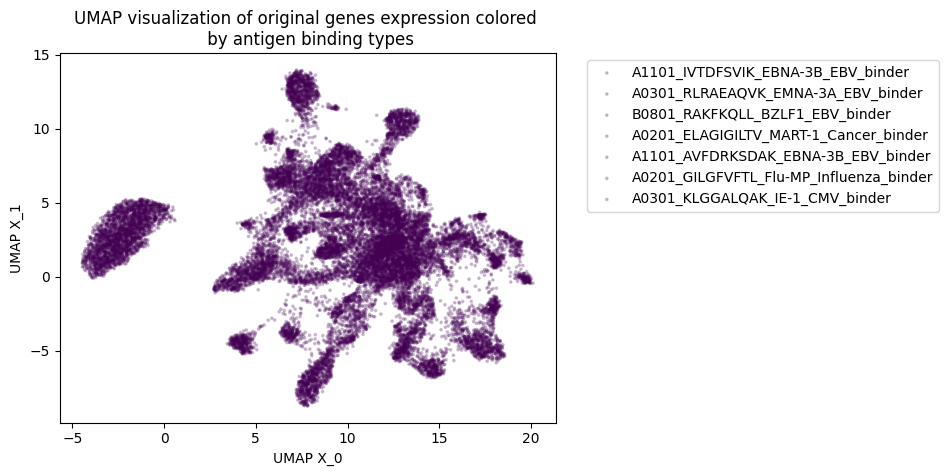

In [43]:
uniq = list(set(adata_emb.obs['antigen'].values))
alpha = 0.2

for i in range(len(uniq)):
    indx = adata_emb.obs['antigen'] == uniq[i]
    plt.scatter(adata_emb.obsm['X_umap'][list(indx),0], adata_emb.obsm['X_umap'][list(indx),1], s=3, c=adata_emb.obs['antigen'].astype('category').cat.codes.values[indx],label=uniq[i], alpha=alpha)

plt.xlabel('UMAP X_0')
plt.ylabel('UMAP X_1')
plt.title('UMAP visualization of original genes expression colored \n by antigen binding types')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.show()

In [44]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
GTGTGCGGTGAGGGTT-5,TRAV1-2,TRBV6-4,None,TRBD1,TRAJ20,TRBJ2-3,TRAC,TRBC1,CAVRDRDYKLSF,CASSDSGGATDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101040,4315.0,3.634981,1562,0.050290,93852,1
TTTACTGTCGGAGGTA-6,TRAV27,TRBV4-1,None,TRBD1,TRAJ26,TRBJ1-2,TRAC,TRBC1,CAGDENYGQNFVF,CASSQVTQGAGYGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101041,4389.0,3.642366,1650,0.064252,93853,0
ACAGCTATCAAACAAG-11,TRAV14DV4,TRBV19,None,TRBD1,TRAJ34,TRBJ2-7,TRAC,TRBC2,CAMREHNTDKLIF,CASKAGTGEYEQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101042,1809.0,3.257439,1028,0.112217,93854,3
TGCCCTAGTATAAACG-7,TRAV17,TRBV9,None,TRBD1,TRAJ40,TRBJ1-1,TRAC,TRBC1,CATAPSGTYKYIF,CASSVDTGFTEAFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101043,1449.0,3.161068,771,0.140787,93855,1
GAACATCCACAACGTT-5,TRAV17,TRBV6-3,None,TRBD1,TRAJ54,TRBJ1-5,TRAC,TRBC1,CATDVQGAQKLVF,CASSYISGGNQPQHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,101046,1748.0,3.242541,910,0.128719,93857,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCGAAAGTCCGAATT-3,TRAV27,TRBV27,None,TRBD1,TRAJ44,TRBJ1-2,TRAC,TRBC1,CAGADGTASKLTF,CASSLSGTWGEGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134642,3745.0,3.573452,1448,0.024833,124079,1
AACTGGTGTGGTAACG-8,TRAV13-2,TRBV5-1,None,None,TRAJ45,TRBJ2-2,TRAC,TRBC2,CAEGGGGADGLTF,CASSLGATNTGELFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134643,2666.0,3.425860,1323,0.171043,124080,0
GACACGCGTCAGAAGC-5,TRAV12-3,TRBV29-1,None,None,TRAJ39,TRBJ1-2,TRAC,TRBC1,CAIGPGNMLTF,CSVDLEANYGYTF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134644,1410.0,3.149219,888,0.119858,124081,2


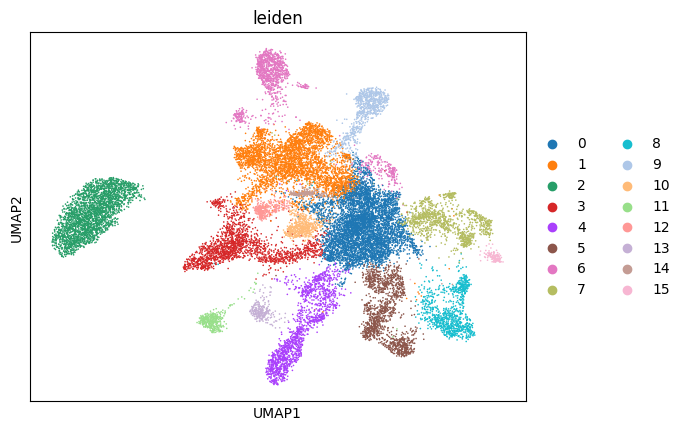

In [45]:
sc.pl.umap(adata_emb, color=['leiden'])

In [46]:
# sc.pl.umap(adata_emb, color=['IR_VDJ_1_junction_aa'])

In [47]:
# data_10X_dat[['cdr3b','Peptide_sequence']].groupby('cdr3b').value_counts().sort_values(ascending=False)

In [48]:
# data_10X_dat[data_10X_dat.cdr3b == "CASSLGFPNQPQHF"]        

In [49]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "TTDPSFLGRY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts().sort_values(ascending=False)        

In [50]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "LTDEMIAQY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts()        

In [51]:
from sklearn.metrics.cluster import normalized_mutual_info_score

In [52]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.002638875716052836


In [53]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.0416690081375964


In [54]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRA'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.04122624162552786


In [55]:
ari_score = adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: -0.001487093383275883


In [56]:
adjusted_rand_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

-4.143337273922563e-05

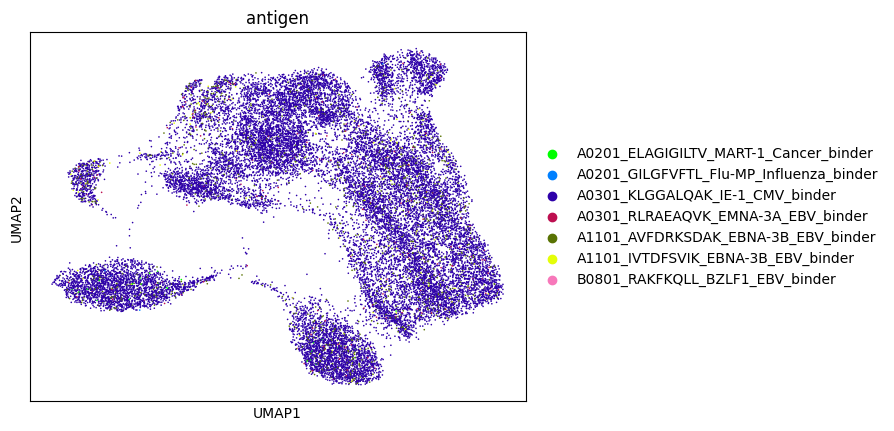

In [57]:
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)